**This notebook is for analyzing the baseline model (models/baseline) and eventually improving upon it**

Imports:

In [1]:
import numpy as np, joblib, json, tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from scipy.optimize import minimize
from sklearn.metrics import log_loss

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
[[16  7  1  2  0]
 [ 4 25  0  5  2]
 [ 0  2 33  2  1]
 [ 4  4  5 37  0]
 [ 0  2  2  2 14]]
              precision    recall  f1-score   support

           0       0.67      0.62      0.64        26
           1       0.62      0.69      0.66        36
           2       0.80      0.87      0.84        38
           3       0.77      0.74      0.76        50
           4       0.82      0.70      0.76        20

    accuracy                           0.74       170
   macro avg       0.74      0.72      0.73       170
weighted avg       0.74      0.74      0.74       170



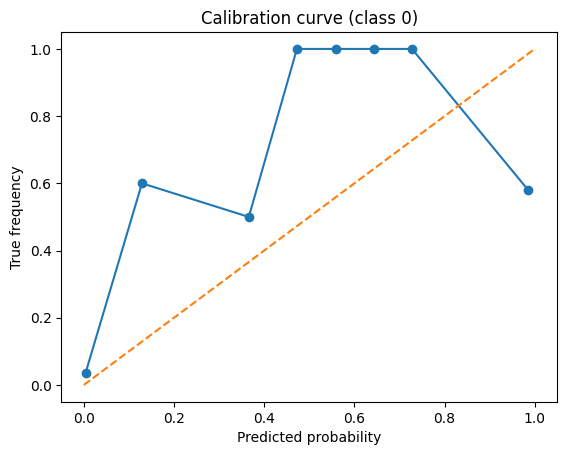

In [2]:

# --- load your saved objects ---
model = tf.keras.models.load_model("models/baseline/model.keras")
bins = np.load("models/baseline/bins.npy")
cfg  = json.load(open("models/baseline/config.json"))

# label_encoder = joblib.load("models/baseline/label_encoder.pkl")  # if you used one
# scaler = joblib.load("models/baseline/scaler.pkl")                # if used

# --- load your test data (same format as training) ---
X_test = np.load("X_test.npy")  # or however you stored it
y_test = np.load("y_test.npy")

# --- get predictions ---
y_pred_proba = model.predict(X_test)
y_pred = y_pred_proba.argmax(axis=1)
y_true = y_test.argmax(axis=1)

# --- confusion matrix ---
cm = confusion_matrix(y_true, y_pred)
print(cm)

# --- per-class metrics ---
print(classification_report(y_true, y_pred))

# --- calibration curve (for one class) ---
prob_true, prob_pred = calibration_curve(y_true == 0, y_pred_proba[:,0], n_bins=10)
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],'--')
plt.xlabel("Predicted probability")
plt.ylabel("True frequency")
plt.title("Calibration curve (class 0)")
plt.show()


**Explanation of above results**

*Confusion matrix*

Each row = true class, each column = predicted class.

Diagonal values = correct predictions → overall, quite strong diagonals.

A few key insights:
- Class 2 and 3 perform very well (most predictions on the diagonal).
- Class 0 and Class 1 show some confusion between each other (cross-predictions in [0,1] and [1,0]).
- Class 4 is smaller (20 samples), but still holds up decently.

*Calibration curve*

Your plot shows a blue line that’s not following the orange dashed line (ideal calibration) — meaning the model’s confidence doesn’t match real accuracy.

**Apply Temperature Scaling**

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Optimal temperature: 5.000
Accuracy (orig): 0.7352941176470589
Accuracy (cal) : 0.7352941176470589


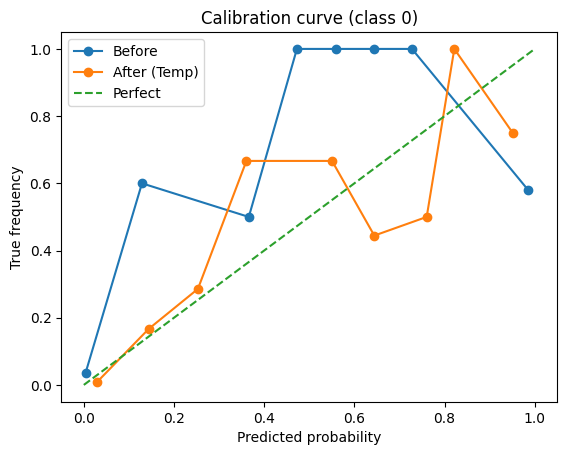

In [4]:
import numpy as np
import tensorflow as tf
from scipy.optimize import minimize
from sklearn.metrics import log_loss, accuracy_score
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# 1) Load model + data
model = tf.keras.models.load_model("models/baseline/model.keras")
X_test = np.load("X_test.npy")
y_test = np.load("y_test.npy")  # one-hot

# 2) Get original probabilities (this also "builds" the model)
probs_orig = model.predict(X_test)

# 3) Pretend-logits = log(p): valid because softmax(log p) == p (up to a constant)
eps = 1e-12
logits = np.log(np.clip(probs_orig, eps, 1.0))

def softmax_from_logits(logits, T=1.0):
    z = logits / T
    z -= z.max(axis=1, keepdims=True)
    ez = np.exp(z)
    return ez / ez.sum(axis=1, keepdims=True)

def nll(T):
    p = softmax_from_logits(logits, T)
    return log_loss(y_test, p)

# 4) Optimize temperature
res = minimize(nll, x0=[1.0], bounds=[(0.5, 5.0)], method="L-BFGS-B")
T_opt = float(res.x[0])
print(f"Optimal temperature: {T_opt:.3f}")

# 5) Calibrated probabilities
probs_cal = softmax_from_logits(logits, T_opt)

# 6) Quick sanity checks
y_true = y_test.argmax(axis=1)
y_pred_orig = probs_orig.argmax(axis=1)
y_pred_cal  = probs_cal.argmax(axis=1)

print("Accuracy (orig):", accuracy_score(y_true, y_pred_orig))
print("Accuracy (cal) :", accuracy_score(y_true, y_pred_cal))  # should be the same

# 7) Calibration plot, before vs after (class 0 as example)
pt_b, pp_b = calibration_curve(y_true == 0, probs_orig[:, 0], n_bins=10)
pt_a, pp_a = calibration_curve(y_true == 0, probs_cal[:, 0],  n_bins=10)

plt.plot(pp_b, pt_b, marker='o', label='Before')
plt.plot(pp_a, pt_a, marker='o', label='After (Temp)')
plt.plot([0,1],[0,1],'--', label='Perfect')
plt.xlabel("Predicted probability")
plt.ylabel("True frequency")
plt.title("Calibration curve (class 0)")
plt.legend()
plt.show()

# 8) Save temperature for later use (e.g., web app)
import json, os
os.makedirs("models/calibrated_v1", exist_ok=True)
json.dump({"T": T_opt}, open("models/calibrated_v1/temperature.json", "w"))


**Refit T on a calibration split, not on the full test set**

Use ~30% of your test set to fit T, keep the rest as a hold-out to report ECE.

In [5]:
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import log_loss

# y_true: integer labels
y_true = y_test.argmax(axis=1)

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=0)
cal_idx, hold_idx = next(sss.split(X_test, y_true))

X_cal, y_cal = X_test[cal_idx], y_test[cal_idx]
X_hold, y_hold = X_test[hold_idx], y_test[hold_idx]

probs_cal0  = model.predict(X_cal)
probs_hold0 = model.predict(X_hold)

logits_cal = np.log(np.clip(probs_cal0, 1e-12, 1.0))

from scipy.optimize import minimize
def softmax_from_logits(L, T=1.0):
    z = L / T
    z -= z.max(axis=1, keepdims=True)
    ez = np.exp(z)
    return ez / ez.sum(axis=1, keepdims=True)

def nll_T(T):
    return log_loss(y_cal, softmax_from_logits(logits_cal, T))

res = minimize(nll_T, x0=[1.0], bounds=[(0.5, 50.0)], method="L-BFGS-B")
T_opt = float(res.x[0])
print("Optimal T (on calib split):", T_opt)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Optimal T (on calib split): 5.601745087867397


**Lock it in (save + tiny wrapper)**

Saves file temperature.json to models/calibrated_v1

In [7]:
import json, numpy as np

# Save the temperature
T_opt = 5.601745087867397
json.dump({"T": float(T_opt)}, open("models/calibrated_v1/temperature.json","w"))

# Reuse the same helper from earlier:
def softmax_from_logits(L, T=1.0):
    z = L / T
    z -= z.max(axis=1, keepdims=True)
    ez = np.exp(z)
    return ez / ez.sum(axis=1, keepdims=True)

def calibrated_probs_from_raw(model, X, T):
    p = model.predict(X)
    logits = np.log(np.clip(p, 1e-12, 1.0))
    return softmax_from_logits(logits, T)


**Quantify the win (ECE + reliability on HOLD-OUT)**

In [8]:
# probs_hold0: original probs on hold-out
# y_hold: one-hot labels on hold-out
probs_hold_cal = calibrated_probs_from_raw(model, X_hold, T_opt)

def ece(probs, y_onehot, n_bins=15):
    y_true = y_onehot.argmax(1)
    conf   = probs.max(1)
    pred   = probs.argmax(1)
    correct = (pred == y_true).astype(float)
    bins = np.linspace(0,1,n_bins+1)
    out = 0.0
    for i in range(n_bins):
        lo, hi = bins[i], bins[i+1]
        idx = (conf > lo) & (conf <= hi)
        if idx.any():
            out += idx.mean() * abs(correct[idx].mean() - conf[idx].mean())
    return out

print("ECE before:", round(ece(probs_hold0,  y_hold), 3))
print("ECE after :", round(ece(probs_hold_cal, y_hold), 3))


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
ECE before: 0.231
ECE after : 0.12


**Add an “abstain if uncertain” rule**

In [9]:
y_true = y_hold.argmax(1)
pred   = probs_hold_cal.argmax(1)
conf   = probs_hold_cal.max(1)
correct = (pred == y_true)

for tau in [0.50, 0.60, 0.70, 0.80, 0.90]:
    keep = conf >= tau
    cov  = keep.mean()
    acc  = correct[keep].mean() if keep.any() else float('nan')
    print(f"τ={tau:.2f}  coverage={cov:.2f}  accepted-acc={acc:.3f}")


τ=0.50  coverage=0.69  accepted-acc=0.800
τ=0.60  coverage=0.51  accepted-acc=0.885
τ=0.70  coverage=0.43  accepted-acc=0.864
τ=0.80  coverage=0.27  accepted-acc=1.000
τ=0.90  coverage=0.18  accepted-acc=1.000
